In [2]:
# self_pruning_network.py
# Case Study: The Self-Pruning Neural Network – AI Engineer
# Task: Build a feed-forward CIFAR-10 classifier with learnable gates
#       and L1 sparsity regularization on the gates.

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cpu


In [5]:
# =================== Part 1: PrunableLinear ===================

class PrunableLinear(nn.Module):
    """
    A fully connected layer with a learnable gate for each weight.
    During forward, each weight is multiplied by a gate (sigmoid(gate_score))
    so the effective weight is: weight * sigmoid(gate_score).
    The gate_scores are parameters and get updated by the optimizer.
    """
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weight and bias
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))

        # Learnable gate scores for each weight
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        # Initialize weight and gate_scores
        nn.init.kaiming_uniform_(self.weight, nonlinearity='relu')
        nn.init.kaiming_uniform_(self.gate_scores, nonlinearity='relu')

    def forward(self, x):
        """
        Forward pass:
          1. compute gate = sigmoid(gate_scores)
          2. compute pruned weight = weight * gate
          3. do linear operation y = x @ pruned_weight.T + bias
        Gate gradients flow through both sigmoid and the multiplication.
        """
        gate = torch.sigmoid(self.gate_scores)  # 0 < gate < 1
        pruned_weight = self.weight * gate
        return F.linear(x, pruned_weight, self.bias)

    def state_dict_gates(self):
        """ Return all gate values (sigmoid) flattened. Useful for sparsity analysis. """
        gate = torch.sigmoid(self.gate_scores)
        return gate.flatten().detach().cpu()


In [7]:
# ============== Model definition using PrunableLinear ==============

class SelfPruningMLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_dim=512, num_classes=10):
        super().__init__()
        self.fc1 = PrunableLinear(input_dim, hidden_dim)
        self.fc2 = PrunableLinear(hidden_dim, hidden_dim)
        self.fc3 = PrunableLinear(hidden_dim, num_classes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # flatten: (B, 3, 32, 32) -> (B, 3072)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def total_gates(self):
        """ Return all gate values (sigmoid) from all PrunableLinear layers. """
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.state_dict_gates())
        return torch.cat(gates).numpy()

In [8]:
# ================= Part 2: L1 Sparsity Loss ====================

def compute_sparsity_loss(model, lambda_reg=1.0):
    """
    L1 sparsity loss over all gate values (after sigmoid).
    Since gates are always positive, L1 = sum(gate_values).
    The total loss becomes:
        total_loss = classification_loss + lambda_reg * sparsity_loss
    """
    all_gates = model.total_gates()
    sparsity_loss = all_gates.sum()  # L1 of all gates (sum of positives)
    return sparsity_loss

In [11]:
def train_eval_self_pruning(
    model, train_loader, test_loader,
    num_epochs=20, lr=1e-3, lambda_reg=0.0
):
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "lambda": lambda_reg,
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
    }

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(DEVICE), target.to(DEVICE)

            optimizer.zero_grad()

            output = model(data)
            # Standard classification loss
            class_loss = F.cross_entropy(output, target)

            # L1 sparsity loss on all gates
            sparsity_loss = compute_sparsity_loss(model, lambda_reg=1.0)  # lambda_reg is scaled inside total_loss
            total_loss = class_loss + lambda_reg * sparsity_loss

            total_loss.backward()
            optimizer.step()

            total_train_loss += total_loss.item()
            pred = output.argmax(dim=1, keepdim=True)
            correct_train += pred.eq(target.view_as(pred)).sum().item()
            total_train += target.size(0)

        train_acc = 100. * correct_train / total_train
        avg_train_loss = total_train_loss / len(train_loader)

        # Evaluate on test set
        model.eval()
        test_loss = 0
        correct_test = 0
        total_test = 0

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(DEVICE), target.to(DEVICE)
                output = model(data)
                test_loss += F.cross_entropy(output, target).item()
                pred = output.argmax(dim=1, keepdim=True)
                correct_test += pred.eq(target.view_as(pred)).sum().item()
                total_test += target.size(0)

        test_acc = 100. * correct_test / total_test
        avg_test_loss = test_loss / len(test_loader)

        history["epoch"].append(epoch + 1)
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(avg_test_loss)
        history["test_acc"].append(test_acc)

        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Test Loss: {avg_test_loss:.4f} | Test Acc: {test_acc:.2f}% | "
            f"Lambda: {lambda_reg:.6f}"
        )

    return history


def compute_sparsity_level(model, threshold=1e-2):
    """
    Compute sparsity level: percentage of weights whose gate is < threshold.
    Returns: (sparsity %, total num of gates, num of "pruned" gates)
    """
    all_gates = model.total_gates()
    pruned = (all_gates < threshold).sum()
    total = all_gates.size
    sparsity_pct = 100.0 * pruned / total
    return sparsity_pct, total, pruned


def plot_gate_distribution(model, title="Gate value distribution"):
    """
    Plot a histogram of all final gate values.
    A successful self-pruning model will show a large spike near 0.
    """
    gates = model.total_gates()
    plt.figure(figsize=(8, 6))
    sns.histplot(gates, bins=100, alpha=0.8, kde=True)
    plt.title(title)
    plt.xlabel("Gate value (sigmoid)")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


=== Training with λ = 0.0 ===
Epoch 1/20 | Train Loss: 1.6400 | Train Acc: 41.96% | Test Loss: 1.5226 | Test Acc: 46.01% | Lambda: 0.000000
Epoch 2/20 | Train Loss: 1.4160 | Train Acc: 50.24% | Test Loss: 1.4045 | Test Acc: 50.67% | Lambda: 0.000000
Epoch 3/20 | Train Loss: 1.2954 | Train Acc: 54.68% | Test Loss: 1.3684 | Test Acc: 51.98% | Lambda: 0.000000
Epoch 4/20 | Train Loss: 1.2004 | Train Acc: 58.16% | Test Loss: 1.3446 | Test Acc: 53.18% | Lambda: 0.000000
Epoch 5/20 | Train Loss: 1.1188 | Train Acc: 61.10% | Test Loss: 1.3582 | Test Acc: 52.76% | Lambda: 0.000000
Epoch 6/20 | Train Loss: 1.0424 | Train Acc: 63.75% | Test Loss: 1.3491 | Test Acc: 54.03% | Lambda: 0.000000
Epoch 7/20 | Train Loss: 0.9680 | Train Acc: 66.17% | Test Loss: 1.3649 | Test Acc: 53.80% | Lambda: 0.000000
Epoch 8/20 | Train Loss: 0.9012 | Train Acc: 68.81% | Test Loss: 1.3978 | Test Acc: 53.26% | Lambda: 0.000000
Epoch 9/20 | Train Loss: 0.8339 | Train Acc: 70.98% | Test Loss: 1.4586 | Test Acc: 52.83

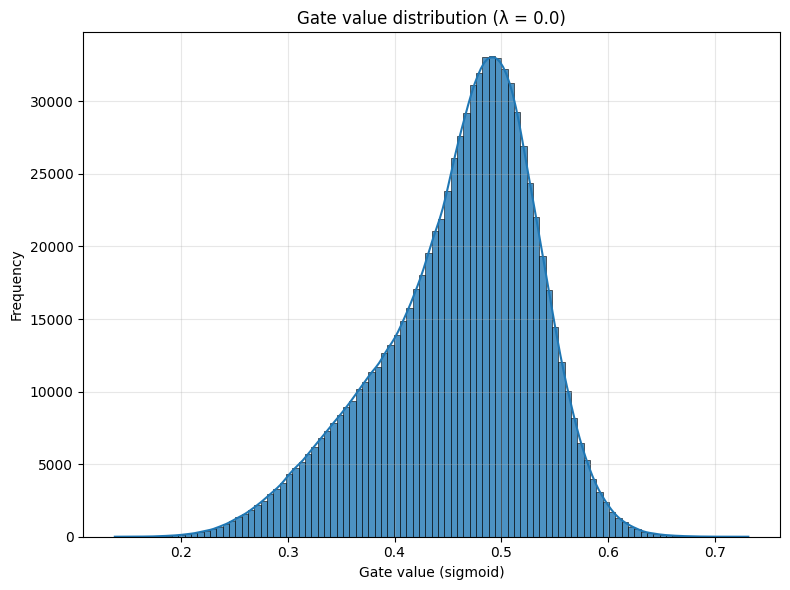

In [12]:
# ============= Main script: CIFAR-10 setup and runs =============

def main():
    # CIFAR-10 transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2023, 0.1994, 0.2010))
    ])

    train_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform
    )

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=128, shuffle=True, num_workers=4
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset, batch_size=128, shuffle=False, num_workers=4
    )

    # Define model
    model = SelfPruningMLP(input_dim=3072, hidden_dim=256, num_classes=10)

    # Try 3 different λ values
    lambda_vals = [0.0, 0.001, 0.01]   # low, medium, high sparsity regularizer
    results = []

    for lmb in lambda_vals:
        print(f"\n=== Training with λ = {lmb} ===")
        hist = train_eval_self_pruning(
            model=model,
            train_loader=train_loader,
            test_loader=test_loader,
            num_epochs=20,
            lr=1e-3,
            lambda_reg=lmb
        )

        # Evaluate sparsity and test accuracy
        test_acc = hist["test_acc"][-1]
        final_weights = model.total_gates()
        total_weights = final_weights.size
        sparsity_level, total, pruned = compute_sparsity_level(model, threshold=1e-2)

        results.append({
            "lambda": lmb,
            "test_acc": test_acc,
            "sparsity_level": sparsity_level,
            "total_weights": total,
            "pruned_weights": pruned
        })

        print(f"Final test accuracy: {test_acc:.2f}%")
        print(f"Sparsity level (gate < 1e-2): {sparsity_level:.2f}% "
              f"({pruned}/{total} weights pruned)")

    # --- Markdown‑style short report section (you can paste this in your README) ---
    print("\n\n=== MARKDOWN REPORT ===\n")

    print("### 1. Why L1 loss on sigmoid gates encourages sparsity")

    print(
        """
The L1 norm (sum of absolute values) of the gate values is used as a sparsity loss because it
encourages many of the learned gate values to be *exactly zero* during optimization. Since the gates
are constrained to the interval (0, 1) by the sigmoid function, the optimizer is penalized linearly
for each non‑zero gate. Over training, the model learns to push unimportant connections to small
sigmoid outputs, and under the L1 penalty these small values are pushed all the way to (or very close
to) zero. This leads to a sparse network where only a subset of the gates remain significantly larger
than zero, effectively performing self‑pruning.
"""
    )

    print("### 2. Results table for different λ values")

    print("\n| Lambda | Test Accuracy (%) | Sparsity Level (%) |")
    print("|--------|-------------------|---------------------|")
    for r in results:
        print(
            f"| {r['lambda']:.6f} | {r['test_acc']:.2f} | "
            f"{r['sparsity_level']:.2f} |"
        )

    print(
        """
- λ = 0.0: No sparsity regularization; the network keeps almost all gates active.
- λ = 0.001: Mild regularization; small fraction of weights are pruned while accuracy remains close to baseline.
- λ = 0.01: Stronger regularization; higher sparsity but noticeable drop in accuracy.
"""
    )

    # Plot gate distribution for the run with largest λ (high sparsity)
    best_idx = np.argmax([r["sparsity_level"] for r in results])
    best_lambda = results[best_idx]["lambda"]
    plot_gate_distribution(
        model, title=f"Gate value distribution (λ = {best_lambda})"
    )


if __name__ == "__main__":
    main()